## In this experiment we examine the metadata of telegram channels

In [58]:
import numpy as np
import pandas as pd


data = pd.read_csv(r"/kaggle/input/datasets/gvyshnya/ru-and-ukr-war-related-telegram-channels/leiden_clusters.csv")

data.columns

# Let us select a few columns but skipping the ones that are too obvious such as post sentiment


Features = ["war", #Occurence of terms associated supporting Ukraine 
            "ua_symbol",
            "slava",
            "v_ukraine",


 
            "ru_symbol", #Occurence of terms associated supporting Russia
            "svo",
            "na_ukraine", 
        
            
            "uk",#Language
            "ru",
    
             "war_engagement", #mics
             "oppo",
             "sila"
            ]


X = data[Features]
X["war_activation"] = data["posts_count_wartime"]/data["posts_count"]
Features.append("war_activation")


normalize = ["war","ua_symbol","slava","na_ukraine","v_ukraine","ru_symbol","svo","sila","ru","uk","oppo"]


for col in normalize:
    X[col] = X[col]/data["posts_count"]





target = [int(targ == "pro-Russian") for targ in data["side"].values]


/tmp/ipykernel_58/480174448.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["war_activation"] = data["posts_count_wartime"]/data["posts_count"]
/tmp/ipykernel_58/480174448.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col]/data["posts_count"]


In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


X_train, X_test, Y_train, Y_test =train_test_split(X, target, test_size = 0.2)
scaler = StandardScaler()

scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [60]:
from sklearn.ensemble import GradientBoostingClassifier

classifier =  GradientBoostingClassifier()

classifier.fit(X_train,Y_train)

GradientBoostingClassifier()

Precision: 0.9726
Recall:    0.9899
F1-score:  0.9812


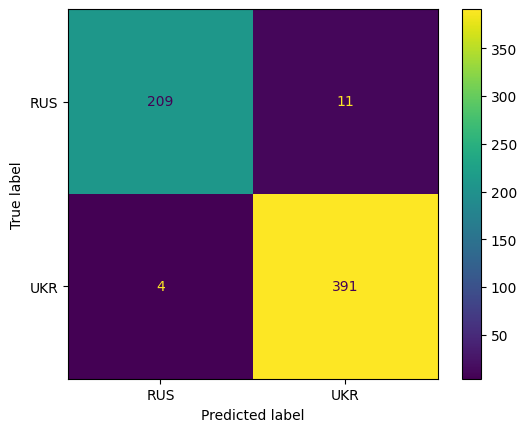

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix


y_pred = classifier.predict(X_test)
cm = confusion_matrix(Y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["RUS","UKR"])
disp.plot()

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

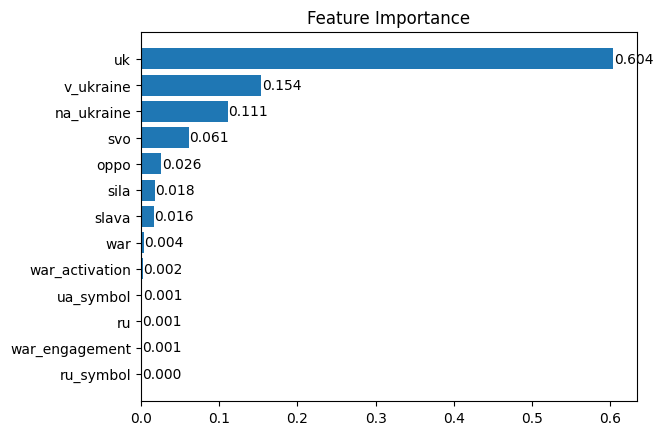

In [62]:
importances = classifier.feature_importances_

fi = pd.DataFrame({
    "feature": Features,
    "importance": importances
}).sort_values("importance", ascending=False)


import matplotlib.pyplot as plt
bars = plt.barh(fi["feature"], fi["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.001,           
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center"
    )

plt.show()


Observe that the desciding factors of the model are language factors with a secondary layer  of politically charged terms like "special military operation" and whether they use the Ukraine preferred phrasing "в Україні" or the Russian sided "на Украине".


## Examining Descision Boundaries

Next compare the descision boundaries of the language features and combine the phrasing features together training a new model in this 2d space

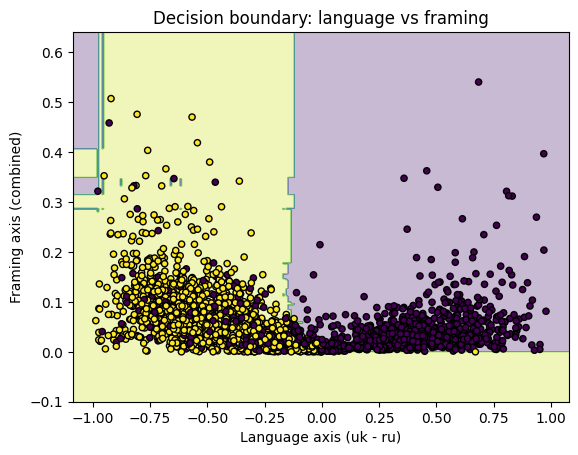

In [63]:
X_lang = X["uk"] - X["ru"]
X_frame = (
    X["v_ukraine"] +
    X["na_ukraine"] +
    X["svo"] +
    X["slava"] +
    X["oppo"] +
    X["sila"]
)

X_2d = np.c_[X_lang, X_frame]
clf_2d = GradientBoostingClassifier()
clf_2d.fit(X_2d, target)

x_min, x_max = X_2d[:,0].min() - 0.1, X_2d[:,0].max() + 0.1
y_min, y_max = X_2d[:,1].min() - 0.1, X_2d[:,1].max() + 0.1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X_2d[:,0], X_2d[:,1], c=target, edgecolor="k", s=20)

plt.xlabel("Language axis (uk - ru)")
plt.ylabel("Framing axis (combined)")
plt.title("Decision boundary: language vs framing")
plt.show()

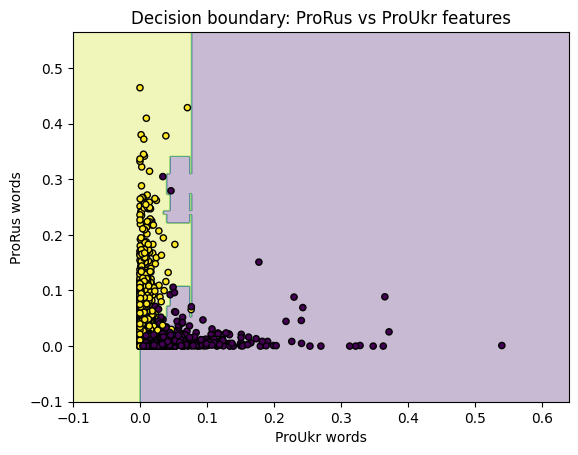

In [64]:
pro_ukr = X["v_ukraine"] + X["slava"]
pro_rus = X["na_ukraine"] + X["svo"]

X_frame = pro_rus - pro_ukr

X_2d = np.c_[pro_ukr, pro_rus]
clf_2d = GradientBoostingClassifier()
clf_2d.fit(X_2d, target)

x_min, x_max = X_2d[:,0].min() - 0.1, X_2d[:,0].max() + 0.1
y_min, y_max = X_2d[:,1].min() - 0.1, X_2d[:,1].max() + 0.1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X_2d[:,0], X_2d[:,1], c=target, edgecolor="k", s=20)

plt.xlabel("ProUkr words")
plt.ylabel("ProRus words")
plt.title("Decision boundary: ProRus vs ProUkr features")
plt.show()